In [1]:
from IPython.display import Markdown, display

display(Markdown("## Cell 1 - English text"))

import asyncio
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

import openai
from src.core.token_estimator import TokenEstimator
from src.core.providers.lmstudio_provider import LMStudioProvider
from src.core.types import OptimizationConstraints, PlanningResult
from src.optimization.positional_anchor import PositionalAnchorer
from src.optimization.word_pruner import WordPruner
from src.optimization.semantic_pruner import SemanticPruner
from src.optimization.formatter import PromptFormatter
from src.optimization.optimizer import Optimizer
from src.planning.planner import Planner

LM_STUDIO_URL = "http://localhost:1234/v1"
te = TokenEstimator()

# English text ID
client = openai.OpenAI(base_url=LM_STUDIO_URL, api_key="lm-studio")
try:
    available_models = [m.id for m in client.models.list().data]
except Exception as e:
    available_models = []
    print(f"WARNING English text LM Studio: {e}")

MODEL_ID = available_models[0] if available_models else "gemma-4-e4b-it"
print(f"English text: {MODEL_ID}")
print(f"English text: {available_models}")

provider = LMStudioProvider(model=MODEL_ID, base_url=LM_STUDIO_URL)


## Cell 1 - English text

English text: gemma-4-e4b-it
English text: ['gemma-4-e4b-it', 'gpt-oss-nano', 'qwen3.5-4b', 'qwen3.5-9b-uncensored-hauhaucs-aggressive', 'qwen3.5-9b-abliterated', 'text-embedding-nomic-embed-text-v1.5']


In [2]:
from IPython.display import Markdown, display

display(Markdown("## Cell 2 - WordPruner English text(English text,English text)"))

import pandas as pd

WORD_PRUNER_CASES = [
    {
        "id": "WP-01",
        "label": "Rule 1 English text",
        "text": "In order to achieve this, please make sure that the system handles errors due to the fact that failures are common.",
    },
    {
        "id": "WP-02",
        "label": "Rule 2 English text",
        "text": "The data needs to be processed and the report must be generated before the deadline.",
    },
    {
        "id": "WP-03",
        "label": "Rule 3 English text",
        "text": "Generate a comprehensive and detailed report that includes the following items: status, errors, and warnings.",
    },
    {
        "id": "WP-04",
        "label": "Rule 1+2+3 English text",
        "text": "In order to achieve the goal, please make sure that the data needs to be processed. Generate a comprehensive and detailed summary that includes the following metrics.",
    },
    {
        "id": "WP-05",
        "label": "Rule 5 English text",
        "text": "The API should output a JSON object containing user_id, status, and timestamp fields.",
    },
    {
        "id": "WP-06",
        "label": "English text(English text)",
        "text": "Implement a JWT authentication middleware for FastAPI with refresh token support.",
    },
]

wp = WordPruner()
wp_summary_rows = []

for case in WORD_PRUNER_CASES:
    original = case["text"]
    compressed, rules = wp.prune(original)
    reduction = wp.estimate_reduction(original, compressed)

    print(f"\n{'=' * 60}")
    print(f"[{case['id']}] {case['label']}")
    print("English text:")
    print(f"  {original}")
    print("English text:")
    print(f"  {compressed}")
    print(f"English text: {reduction:.1%}")
    print(f"English text: {rules if rules else 'English text'}")

    wp_summary_rows.append({
        "English text ID": case["id"],
        "English text": case["label"],
        "English text": len(original),
        "English text": len(compressed),
        "English text": f"{reduction:.1%}",
        "English text": len(rules),
    })

wp_summary_df = pd.DataFrame(wp_summary_rows)
display(wp_summary_df)


## Cell 2 - WordPruner English text(English text,English text)


[WP-01] Rule 1 English text
English text:
  In order to achieve this, please make sure that the system handles errors due to the fact that failures are common.
English text:
  to achieve this, ensure the system handles errors because failures are common.
English text: 32.2%
English text: ['Rule 1 - redundant phrase elimination']

[WP-02] Rule 2 English text
English text:
  The data needs to be processed and the report must be generated before the deadline.
English text:
  The data process and the report generat before the deadline.
English text: 28.6%
English text: ['Rule 2 - passive voice simplification']

[WP-03] Rule 3 English text
English text:
  Generate a comprehensive and detailed report that includes the following items: status, errors, and warnings.
English text:
  generate a report including items: status, errors, and warnings.
English text: 41.3%
English text: ['Rule 3 - nested modifier simplification']

[WP-04] Rule 1+2+3 English text
English text:
  In order to achieve th

,English text ID,English text,English text,English text,English text,English text
0,WP-01,Rule 1 English text,115,78,32.2%,1
1,WP-02,Rule 2 English text,84,60,28.6%,1
2,WP-03,Rule 3 English text,109,64,41.3%,1
3,WP-04,Rule 1+2+3 English text,166,83,50.0%,3
4,WP-05,Rule 5 English text,85,113,0.0%,1
5,WP-06,English text(English text),81,81,0.0%,0


In [3]:
from IPython.display import Markdown, display

display(Markdown("## Cell 3 - PositionalAnchorer English text"))

ANCHOR_CASES = [
    {
        "id": "PA-01",
        "label": "English text",
        "raw_prompt": "Build a JWT authentication API using Python FastAPI, return JSON responses.",
        "planning_result": PlanningResult(
            detectedIntent="Build a JWT authentication API",
            scene="vibe_coding", missingFields=[],
            refinedRequirements=[
                "Role: backend developer",
                "Task: Build a JWT authentication API",
                "Stack: Python FastAPI",
                "Format: return JSON responses",
            ],
            instructionRefs=["vibe_coding"],
        ),
    },
    {
        "id": "PA-02",
        "label": "English text Format English text(English text)",
        "raw_prompt": "Implement a CSV parser in Python with pandas.",
        "planning_result": PlanningResult(
            detectedIntent="Implement a CSV parser",
            scene="vibe_coding", missingFields=[],
            refinedRequirements=[
                "Role: developer",
                "Task: Implement a CSV parser",
                "Stack: Python pandas",
            ],
            instructionRefs=["vibe_coding"],
        ),
    },
    {
        "id": "PA-03",
        "label": "English text Task(English text)",
        "raw_prompt": "Write a sorting algorithm.",
        "planning_result": PlanningResult(
            detectedIntent="Write a sorting algorithm",
            scene="vibe_coding", missingFields=[],
            refinedRequirements=["Task: Write a sorting algorithm"],
            instructionRefs=["vibe_coding"],
        ),
    },
]

anchorer = PositionalAnchorer()

for case in ANCHOR_CASES:
    raw_prompt = case["raw_prompt"]
    planning_result = case["planning_result"]
    segments = anchorer.reorder(anchorer.segment(raw_prompt, planning_result))
    structured = anchorer.to_structured_prompt(segments)

    print(f"\n{'=' * 60}")
    print(f"[{case['id']}] {case['label']}")
    print("Segments:")
    for segment in segments:
        preview = segment.content[:50].replace("\n", " ")
        print(f"  ({segment.position}, {segment.section_type}, {preview!r})")

    print("\nEnglish text:")
    print(structured)

    if any(s.section_type == "role" for s in segments):
        assert "## Role" in structured
    if any(s.section_type == "task" for s in segments):
        assert "## Task" in structured
    assert "## Output Format" in structured

    positions = [s.position for s in segments]
    if "head" in positions and "tail" in positions:
        assert max(i for i, p in enumerate(positions) if p == "head") < min(i for i, p in enumerate(positions) if p == "tail")

    print("PASS English text")


## Cell 3 - PositionalAnchorer English text


[PA-01] English text
Segments:
  (head, role, 'backend developer')
  (head, task, 'Build a JWT authentication API')
  (middle, context, 'using , .')
  (middle, constraint, 'Python FastAPI')
  (tail, format, 'return JSON responses')

English text:
## Role
backend developer

## Task
Build a JWT authentication API

## Context
using , .

## Constraints
Python FastAPI

## Output Format
return JSON responses
PASS English text

[PA-02] English text Format English text(English text)
Segments:
  (head, role, 'developer')
  (head, task, 'Implement a CSV parser')
  (middle, context, 'in Python with pandas.')
  (middle, constraint, 'Python pandas')
  (tail, format, 'Return clean, well-structured output.')

English text:
## Role
developer

## Task
Implement a CSV parser

## Context
in Python with pandas.

## Constraints
Python pandas

## Output Format
Return clean, well-structured output.
PASS English text

[PA-03] English text Task(English text)
Segments:
  (head, task, 'Write a sorting algorithm

In [4]:
from IPython.display import Markdown, display

display(Markdown("## Cell 4 - English text:Planning -> Optimization(English text LM Studio)"))

E2E_CASES = [
    {
        "id": "E2E-01",
        "label": "English text prompt",
        "prompt": (
            "English text,English text."
            "English text,English text."
            "English text Python English text FastAPI English text,English text JSON English text."
            "English text,English text."
        ),
    },
    {
        "id": "E2E-02",
        "label": "English text prompt",
        "prompt": (
            "In order to achieve the goal of building a user management system, "
            "please make sure that you implement the following features. "
            "Due to the fact that security is very critical, the system needs to be "
            "built using React 18 and TypeScript with proper authentication. "
            "It is important to note that all components must include type hints and error handling."
        ),
    },
    {
        "id": "E2E-03",
        "label": "English text prompt(English text)",
        "prompt": (
            "Build a REST API endpoint using FastAPI and Python 3.11. "
            "Endpoint: POST /users/register. "
            "Input: email, password, username. "
            "Output: JSON with user_id and created_at. "
            "Include input validation and return 422 on invalid input."
        ),
    },
    {
        "id": "E2E-04",
        "label": "English text prompt(English text ROI skip)",
        "prompt": "write a sort function",
    },
]

# requirePositiveROI=False English text(English text ROI English text,English text).
# English text requirePositiveROI=True,E2E-04 English text prompt English text ROI English text skip.
optimizer = Optimizer(
    model_provider=provider,
    token_estimator=te,
    constraints=OptimizationConstraints(
        maxCompressionRate=0.50,
        minQualityScore=6.0,
        requirePositiveROI=False,
        maxSelfCorrectionRetries=2,
    ),
)
planner = Planner(model_provider=provider, refs_dir=str(PROJECT_ROOT / "src/planning/instruction_refs"))

e2e_results = []

for case in E2E_CASES:
    try:
        planning_result = await planner.plan(case["prompt"])
        opt_result = await optimizer.optimize(case["prompt"], planning_result)
        e2e_results.append({"case": case, "planning_result": planning_result, "opt_result": opt_result, "error": None})

        print(f"\n{'=' * 60}")
        print(f"[{case['id']}] {case['label']}")
        print(f"English text Prompt ({opt_result.tokenStats.originalCount} tokens):")
        print(f"  {case['prompt'][:100]}...")
        print(f"\nEnglish text Prompt ({opt_result.tokenStats.optimizedCount} tokens):")
        print(opt_result.optimizedPrompt)
        print("\nToken English text:")
        print(f"  English text: {opt_result.tokenStats.originalCount}")
        print(f"  English text: {opt_result.tokenStats.optimizedCount}")
        print(f"  English text: {opt_result.tokenStats.reductionRate:.1%}")
        print(f"  ROI English text: {opt_result.roiReport.netTokenSavings} tokens")
        print(f"  ROI English text: {opt_result.roiReport.roiPositive}")
        print(f"  English text: {opt_result.optimizationSkipped}")
        if opt_result.skipReason:
            print(f"  English text: {opt_result.skipReason}")
        print(f"  English text: {opt_result.appliedTechniques}")
        print(f"  English text: {[(s.position, s.type) for s in opt_result.structureMap]}")

    except Exception as e:
        e2e_results.append({"case": case, "planning_result": None, "opt_result": None, "error": e})
        print(f"FAIL [{case['id']}] English text: {type(e).__name__}: {e}")


## Cell 4 - English text:Planning -> Optimization(English text LM Studio)


[E2E-01] English text prompt
English text Prompt (109 tokens):
  English text,English text.English text,English text.English text Python English text FastAPI English text,English text JSON English text...

English text Prompt (230 tokens):
## Role
developer

## Task
English text,English text.

## Context
English text,English text. English text,English text. English text Python English text FastAPI English text, English text,English text.

## Constraints
- English text Python English text FastAPI English text;English text,English text.

## Output Format
English text JSON English text.

<!-- JSON Schema:
{
  "type": "object",
  "properties": {}
}
-->

## Reminder
English text,English text.

Token English text:
  English text: 109
  English text: 230
  English text: -111.0%
  ROI English text: -321 tokens
  ROI English text: False
  English text: False
  English text: ['positional anchoring', 'semantic pruning']
  English text: [('head', 'role'), ('head', 'task'), ('middle', 'context'), 


[E2E-02] English text prompt
English text Prompt (65 tokens):
  In order to achieve the goal of building a user management system, please make sure that you impleme...

English text Prompt (117 tokens):
## Role
developer

## Task
Building a user management system with specific features.

## Context
to achieve the goal of building a user management system, ensure you implement the following features. because security is critical, the system needs to be built using React 18 and TypeScript with proper authentication. all components must include type hints and error handling.

## Constraints
- React 18 and TypeScript, requiring proper authentication, type hints in all components, and error handling.

## Output Format
Return clean, well-structured output.

## Reminder
Building a user management system with specific features.

Token English text:
  English text: 65
  English text: 117
  English text: -80.0%
  ROI English text: -252 tokens
  ROI English text: False
  English text: False
  En


[E2E-03] English text prompt(English text)
English text Prompt (51 tokens):
  Build a REST API endpoint using FastAPI and Python 3.11. Endpoint: POST /users/register. Input: emai...

English text Prompt (143 tokens):
## Role
developer

## Task
Build a REST API endpoint for user registration.

## Context
Build a REST API endpoint using FastAPI and Python 3. Endpoint: POST /users/register. Input: email, password, username. Output: JSON with user_id and created_at. Include input validation and return 422 on invalid input.

## Constraints
- FastAPI and Python 3.11; must include input validation and return HTTP status code 422 on invalid input.

## Output Format
JSON with user_id and created_at upon successful creation.

<!-- JSON Schema:
{
  "type": "object",
  "properties": {}
}
-->

## Reminder
Build a REST API endpoint for user registration.

Token English text:
  English text: 51
  English text: 143
  English text: -180.4%
  ROI English text: -292 tokens
  ROI English text: False
  En


[E2E-04] English text prompt(English text ROI skip)
English text Prompt (4 tokens):
  write a sort function...

English text Prompt (32 tokens):
## Role
developer

## Task
write a sort function

## Output Format
Return clean, well-structured output.

## Reminder
write a sort function

Token English text:
  English text: 4
  English text: 32
  English text: -700.0%
  ROI English text: -228 tokens
  ROI English text: False
  English text: False
  English text: ['positional anchoring']
  English text: [('head', 'role'), ('head', 'task'), ('tail', 'format')]


## Cell 5 - English text + Token English text

,English text ID,English text,English text tokens,English text tokens,English text,ROI English text,skip,English text
0,E2E-01,English text prompt,109,230,-111.0%,-321,False,2
1,E2E-02,English text prompt,65,117,-80.0%,-252,False,4
2,E2E-03,English text prompt(English text),51,143,-180.4%,-292,False,2
3,E2E-04,English text prompt(English text ROI skip),4,32,-700.0%,-228,False,1


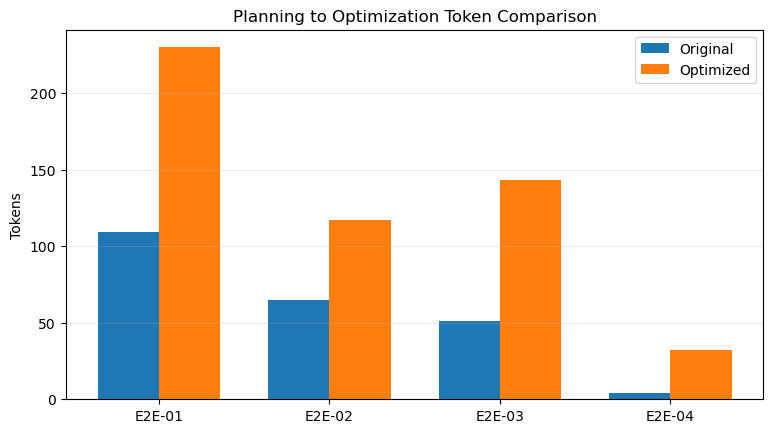


English text:
English text prompt English text WordPruner English text,English text;English text prompt English text,English text;English text prompt English text token English text,English text requirePositiveROI=True English text skip.


In [5]:
from IPython.display import Markdown, display

display(Markdown("## Cell 5 - English text + Token English text"))

import pandas as pd

summary_rows = []
for item in e2e_results:
    case = item["case"]
    opt_result = item["opt_result"]
    if opt_result is None:
        summary_rows.append({
            "English text ID": case["id"],
            "English text": case["label"],
            "English text tokens": None,
            "English text tokens": None,
            "English text": None,
            "ROI English text": None,
            "skip": "ERROR",
            "English text": 0,
        })
        continue

    summary_rows.append({
        "English text ID": case["id"],
        "English text": case["label"],
        "English text tokens": opt_result.tokenStats.originalCount,
        "English text tokens": opt_result.tokenStats.optimizedCount,
        "English text": f"{opt_result.tokenStats.reductionRate:.1%}",
        "ROI English text": opt_result.roiReport.netTokenSavings,
        "skip": opt_result.optimizationSkipped,
        "English text": len(opt_result.appliedTechniques),
    })

e2e_summary_df = pd.DataFrame(summary_rows)
display(e2e_summary_df)

plot_rows = [row for row in summary_rows if row["English text tokens"] is not None and row["English text tokens"] is not None]

try:
    import matplotlib.pyplot as plt

    labels = [row["English text ID"] for row in plot_rows]
    original_counts = [row["English text tokens"] for row in plot_rows]
    optimized_counts = [row["English text tokens"] for row in plot_rows]
    x = range(len(labels))
    width = 0.36

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar([i - width / 2 for i in x], original_counts, width, label="Original")
    ax.bar([i + width / 2 for i in x], optimized_counts, width, label="Optimized")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel("Tokens")
    ax.set_title("Planning to Optimization Token Comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()
except Exception as e:
    print(f"matplotlib English text,English text: {type(e).__name__}: {e}\n")
    max_tokens = max([row["English text tokens"] for row in plot_rows] or [1])
    for row in plot_rows:
        original = row["English text tokens"]
        optimized = row["English text tokens"]
        reduction = 0 if original == 0 else (original - optimized) / original
        filled = int((optimized / max_tokens) * 20) if max_tokens else 0
        empty = max(0, 20 - filled)
        print(f"{row['English text ID']}: {'#' * filled}{'-' * empty} {original} -> {optimized} tokens ({reduction:.1%})")

print("\nEnglish text:")
print("English text prompt English text WordPruner English text,English text;English text prompt English text,English text;English text prompt English text token English text,English text requirePositiveROI=True English text skip.")


In [6]:
from IPython.display import Markdown, display

display(Markdown("## Cell 6 - English text(English text LM Studio)"))

from src.optimization.positional_anchor import PositionalAnchorer, PromptSegment
from src.optimization.word_pruner import WordPruner
from src.optimization.formatter import PromptFormatter
from src.core.types import PlanningResult

# 1 WordPruner English text
wp = WordPruner()
text, rules = wp.prune("in order to achieve X, please make sure that it works")
assert "to achieve X" in text
assert "ensure" in text
assert len(rules) >= 1
print(f"PASS WordPruner Rule 1: {rules}")

text2, rules2 = wp.prune("the data needs to be processed")
assert "Rule 2" in str(rules2)
print(f"PASS WordPruner Rule 2: {rules2}")

_, rules_clean = wp.prune("implement a JWT auth module")
assert rules_clean == []
print("PASS WordPruner English text")

# 2 PositionalAnchorer English text
anchorer = PositionalAnchorer()
pr = PlanningResult(
    detectedIntent="build a REST API",
    scene="vibe_coding", missingFields=[],
    refinedRequirements=[
        "Role: developer",
        "Task: build a REST API",
        "Stack: python fastapi",
        "Format: return JSON",
    ],
    instructionRefs=["vibe_coding"],
)
segs = anchorer.reorder(anchorer.segment("Build a REST API with FastAPI.", pr))
positions = [s.position for s in segs]
assert "head" in positions and "tail" in positions
structured = anchorer.to_structured_prompt(segs)
assert "## Role" in structured
assert "## Task" in structured
assert "## Output Format" in structured
print(f"PASS PositionalAnchorer English text: {[(s.position, s.section_type) for s in segs]}")

# 3 PromptFormatter English text
formatter = PromptFormatter()
output = formatter.format(segs, pr)
assert "## Reminder" in output
assert "build a REST API" in output
print("PASS PromptFormatter Reminder English text")

# 4 inject_json_schema English text
result = formatter.inject_json_schema("output a json object with status and data")
assert "<!-- JSON Schema:" in result
result2 = formatter.inject_json_schema("return clean code")
assert "<!-- JSON Schema:" not in result2
print("PASS inject_json_schema English text/English text")

# ⑤ token English text
from src.core.token_estimator import TokenEstimator
te = TokenEstimator()
original = "In order to achieve X please make sure that it works and needs to be done"
compressed, _ = WordPruner().prune(original)
rate = te.compare_report(original, compressed)
print(f"PASS TokenEstimator English text: {rate.original_tokens} -> {rate.optimized_tokens} tokens ({rate.reduction_percent:.1f}% English text)")

print("\n=== English text ===")


## Cell 6 - English text(English text LM Studio)

PASS WordPruner Rule 1: ['Rule 1 - redundant phrase elimination']
PASS WordPruner Rule 2: ['Rule 2 - passive voice simplification']
PASS WordPruner English text
PASS PositionalAnchorer English text: [('head', 'role'), ('head', 'task'), ('middle', 'context'), ('middle', 'constraint'), ('tail', 'format')]
PASS PromptFormatter Reminder English text
PASS inject_json_schema English text/English text
PASS TokenEstimator English text: 16 -> 11 tokens (31.2% English text)

=== English text ===
